# 🕰️ Modelo de Defasagem Temporal — modelo final da Fase 3

Prevê se um município fica **em risco educacional** no ano seguinte usando
**apenas informação do ano anterior** — o cenário útil de verdade: um gestor
público só age a tempo se souber do risco *antes* do resultado da prova sair.

- **Unidade:** (município, ano). **Target:** `em_risco = taxa_alfabetizacao <
  taxa_media_nacional[ano]` (classe positiva = risco).
- **Features:** só `*_ant` (ano anterior). Prova de que features do mesmo ano
  vazam o alvo: `03a_diagnostico_vazamento_dados.ipynb`.

> Toda a lógica vive em `src/`: `config` (parâmetros), `preprocessing.features`
> (dados), `modeling.pipeline_modelo_d` (pipeline), `evaluation` (métricas e
> interpretabilidade), `visualization.plots` (figuras). Este notebook orquestra.


In [1]:
import sys; sys.path.append("..")
import warnings; warnings.filterwarnings("ignore")

from src import config
from src.preprocessing.gold_consumer import load_gold
from src.preprocessing.features import build_lagged_frame, ref_nacional_por_ano
from src.modeling.pipeline_modelo_d import build_pipeline, predict_ano_seguinte
from src.evaluation import metrics, interpretability
from src.visualization import plots

gold = load_gold(config.GOLD_DATASET)
ref = ref_nacional_por_ano(load_gold(config.GOLD_REF_NACIONAL))
frame = build_lagged_frame(gold, ref)

X = frame[config.FEATURE_COLS]
y = frame[config.TARGET_COL]
groups = frame[config.GROUP_COL]
print(f"{len(frame)} municípios | {y.mean():.1%} em risco | {groups.nunique()} UFs | features: {config.FEATURE_COLS}")
frame.head()


2026-09-05 13:27:20 [INFO] Usando cache local: data\gold\indicador_municipio.parquet


2026-09-05 13:27:20 [INFO] Usando cache local: data\gold\painel_nacional.parquet


5480 municípios | 37.8% em risco | 24 UFs | features: ['taxa_alfabetizacao_ant', 'media_portugues_ant', 'percentual_participacao_ant']


,id_municipio,ano,cod_uf,taxa_alfabetizacao_atual,ref_nacional,em_risco,nao_bate_meta,taxa_alfabetizacao_ant,media_portugues_ant,percentual_participacao_ant
0,1100015,2024,11,67.79,57.36,0,0,64.55,758.33,89.37
1,1100023,2024,11,65.62,57.36,0,0,62.30,757.10,89.79
2,1100031,2024,11,75.88,57.36,0,0,69.10,767.88,90.48
3,1100049,2024,11,66.42,57.36,0,0,64.00,758.22,84.44
4,1100056,2024,11,66.81,57.36,0,0,58.53,746.46,92.12


## 1. As 3 features e sua relação com o alvo

taxa_alfabetizacao_ant        -0.511
media_portugues_ant           -0.504
percentual_participacao_ant   -0.295
Name: em_risco, dtype: float64


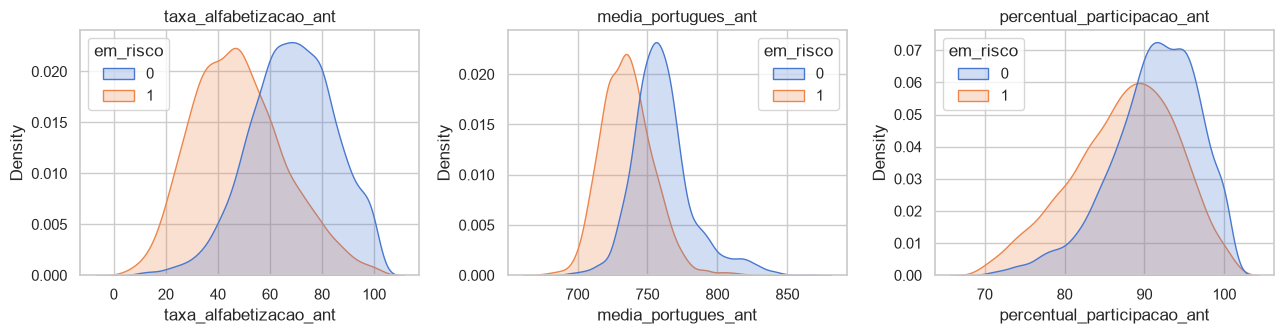

In [2]:
import matplotlib.pyplot as plt, seaborn as sns
print(frame[config.FEATURE_COLS + [config.TARGET_COL]].corr()[config.TARGET_COL].drop(config.TARGET_COL).round(3))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, col in zip(axes, config.FEATURE_COLS):
    sns.kdeplot(data=frame, x=col, hue=config.TARGET_COL, common_norm=False, fill=True, ax=ax)
    ax.set_title(col)
plt.tight_layout(); plt.show()


## 2. Divisão treino/teste

**Holdout estratificado (20%)** — cada município aparece uma vez no frame (só há
linhas de 2024), então um split aleatório já é holdout limpo, sem group leakage.

⚠️ **Não é validação temporal.** Com 2 anos há uma única transição no tempo; a
robustez espacial é checada na seção 3 com `GroupKFold` por UF.


In [3]:
from sklearn.model_selection import StratifiedShuffleSplit
tr, te = next(StratifiedShuffleSplit(1, test_size=0.2, random_state=config.RANDOM_STATE).split(X, y))
X_train, X_test, y_train, y_test = X.iloc[tr], X.iloc[te], y.iloc[tr], y.iloc[te]
print(f"treino {len(tr)} ({y_train.mean():.1%} risco) | teste {len(te)} ({y_test.mean():.1%} risco)")


treino 4384 (37.8% risco) | teste 1096 (37.9% risco)


## 3. Baseline + comparação de modelos

`metrics.comparar_modelos` roda `DummyClassifier` + 4 modelos na **mesma
pipeline**, avaliados por `GroupKFold` por UF (cada fold testa em estados fora
do treino).


In [4]:
comparacao = metrics.comparar_modelos(X, y, groups)
comparacao


,ROC-AUC,PR-AUC,recall_risco,precision_risco,accuracy
modelo,,,,,
Baseline (classe majoritária),0.500,0.378,0.000,0.000,0.622
Regressão Logística,0.836,0.755,0.755,0.625,0.731
Árvore de Decisão,0.806,0.707,0.723,0.656,0.752
Random Forest,0.822,0.749,0.713,0.663,0.754
Gradient Boosting,0.817,0.747,0.610,0.721,0.763


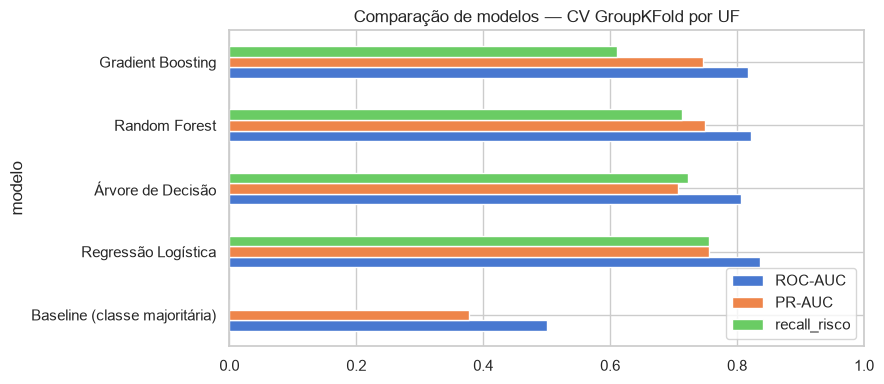

In [5]:
plots.comparacao_modelos(comparacao); plt.show()


**Leitura:** com 3 features e sinal quase linear, a **Regressão Logística**
entrega o melhor ROC-AUC / PR-AUC e o melhor **recall da classe de risco** — a
métrica que importa para política pública. É o modelo final
(`src/config.FINAL_MODEL`).


## 4. Modelo final — avaliação no holdout

In [6]:
pipe = build_pipeline().fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print(metrics.relatorio_classificacao(y_test, y_pred))
h = metrics.holdout_metrics(pipe, X_test, y_test)
print(f"ROC-AUC {h['roc_auc']:.3f} | PR-AUC {h['pr_auc']:.3f} | "
      f"recall_risco {h['recall_risco']:.3f} | baseline {h['baseline_acuracia']:.1%}")
h


               precision    recall  f1-score   support

fora de risco       0.83      0.72      0.77       681
     EM RISCO       0.62      0.76      0.68       415

     accuracy                           0.73      1096
    macro avg       0.73      0.74      0.73      1096
 weighted avg       0.75      0.73      0.74      1096

ROC-AUC 0.817 | PR-AUC 0.749 | recall_risco 0.757 | baseline 62.1%


{'accuracy': 0.7344890510948905,
 'precision_risco': 0.623015873015873,
 'recall_risco': 0.7566265060240964,
 'f1_risco': 0.6833514689880305,
 'roc_auc': 0.8169063920881764,
 'pr_auc': 0.7489404178572809,
 'baseline_acuracia': np.float64(0.6213503649635037),
 'prevalencia_risco': 0.37864963503649635,
 'confusao': {'tn': 491, 'fp': 190, 'fn': 101, 'tp': 314},
 'n_teste': 1096}

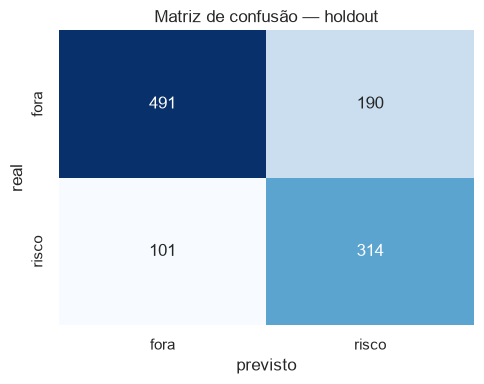

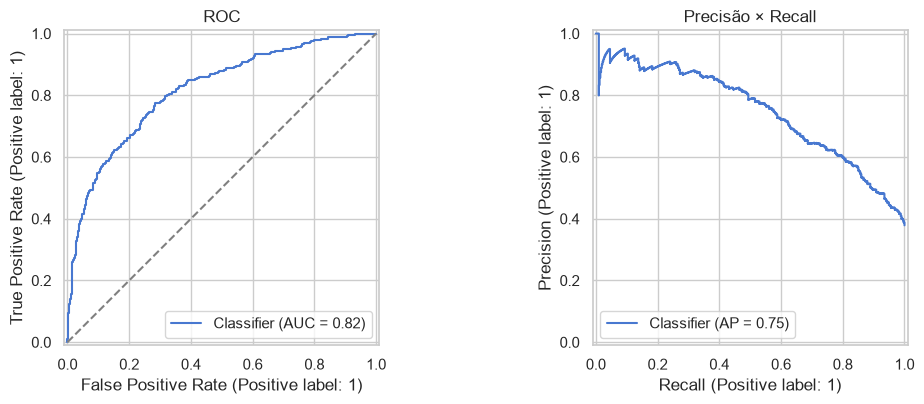

In [7]:
y_proba = pipe.predict_proba(X_test)[:, 1]
plots.matriz_confusao(y_test, y_pred); plt.show()
plots.curvas_roc_pr(y_test, y_proba); plt.show()


## 5. Interpretabilidade — quais fatores pesam

In [8]:
interpretability.tabela_coeficientes(pipe)


,coef,odds_ratio
media_portugues_ant,-1.282,0.277
percentual_participacao_ant,-0.383,0.682
taxa_alfabetizacao_ant,-0.251,0.778


In [9]:
interpretability.tabela_permutation_importance(pipe, X_test, y_test)


,importancia,desvio
media_portugues_ant,0.2741,0.0205
percentual_participacao_ant,0.0434,0.0084
taxa_alfabetizacao_ant,0.0096,0.0050


2026-09-05 13:27:41 [WARNING] Background dataset has 1096 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1096 when initializing the masker.


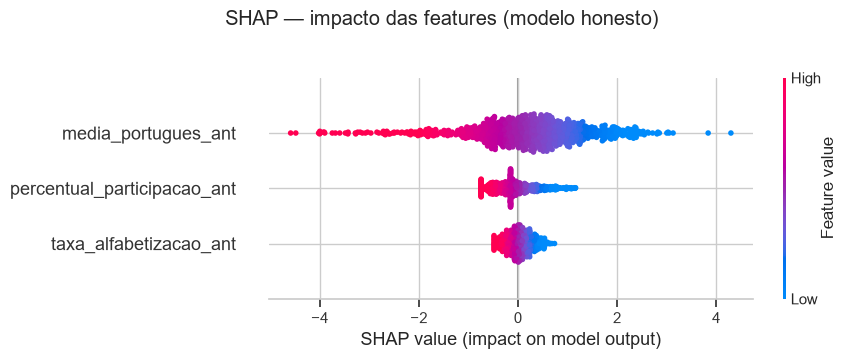

In [10]:
sv = interpretability.shap_explanation(pipe, X_test)
plots.shap_summary(sv); plt.show()


**Leitura:** `media_portugues_ant` é o fator dominante — a nota de português do
ano anterior praticamente já diz se o município está abaixo da média nacional.
Todos no sentido esperado: pior ano anterior → maior risco.

⚠️ **Limite:** os fatores são todos medidas do *próprio desempenho passado*. A
Gold não traz variáveis de contexto (renda, investimento, formação docente) que
apontem *alavancas* de política pública.


## 6. Achado — prever "bater a meta anual" é quase ruído

O desafio pede prever quem "não vai atingir a meta". Testamos esse alvo direto
(`nao_bate_meta = taxa < meta_ano_vigente`), mesmas features, mesma validação:


In [11]:
from sklearn.model_selection import cross_validate, GroupKFold
sub = frame.dropna(subset=[config.TARGET_META])
Xs, ys, gs = sub[config.FEATURE_COLS], sub[config.TARGET_META].astype(int), sub[config.GROUP_COL]
r = cross_validate(build_pipeline(), Xs, ys, groups=gs, cv=GroupKFold(config.CV_FOLDS),
                   scoring=["roc_auc", "average_precision", "recall"], n_jobs=-1)
print(f"nao_bate_meta | prevalência {ys.mean():.1%}")
print(f"  ROC-AUC {r['test_roc_auc'].mean():.3f}  PR-AUC {r['test_average_precision'].mean():.3f}  recall {r['test_recall'].mean():.3f}")

delta = frame.taxa_alfabetizacao_atual - frame.taxa_alfabetizacao_ant
print(f"\nΔ taxa ano a ano: desvio {delta.std():.1f} p.p. — a meta é fixada ~1 p.p. acima da taxa")
print("anterior, então cruzar ou não a meta num ano é dominado por esse ruído.")


nao_bate_meta | prevalência 46.0%
  ROC-AUC 0.598  PR-AUC 0.546  recall 0.525

Δ taxa ano a ano: desvio 16.4 p.p. — a meta é fixada ~1 p.p. acima da taxa
anterior, então cruzar ou não a meta num ano é dominado por esse ruído.


**Conclusão do achado:** dá para identificar bem quem está **estruturalmente
atrás** (target `em_risco`), mas **não** para cravar quem vai falhar a meta de
um ano específico. É uma limitação dos dados, não do modelo — resultado honesto
que vale reportar.


## 7. Aplicação — ranking de risco e previsão do próximo ano

In [12]:
import joblib
pipe_final = joblib.load(config.MODEL_PATH) if config.MODEL_PATH.exists() else build_pipeline().fit(X, y)
ano_base = int(gold.ano.max())
pred = predict_ano_seguinte(pipe_final, gold, ano_base).sort_values("prob_risco", ascending=False)
print(f"Previsão de risco para {ano_base + 1} (extrapolação — não validada): "
      f"{pred.em_risco.sum()}/{len(pred)} municípios sinalizados ({pred.em_risco.mean():.1%})")
pred.head(15)


Previsão de risco para 2025 (extrapolação — não validada): 2061/5516 municípios sinalizados (37.4%)


,id_municipio,cod_uf,prob_risco,em_risco
1154,2408706,24,0.985535,1
347,1707702,17,0.981304,1
368,1712702,17,0.978131,1
1219,2414456,24,0.977179,1
68,1200435,12,0.975666,1
1166,2409803,24,0.970391,1
178,1502806,15,0.967945,1
365,1712405,17,0.967909,1
2055,2920908,29,0.967250,1
331,1704600,17,0.966736,1


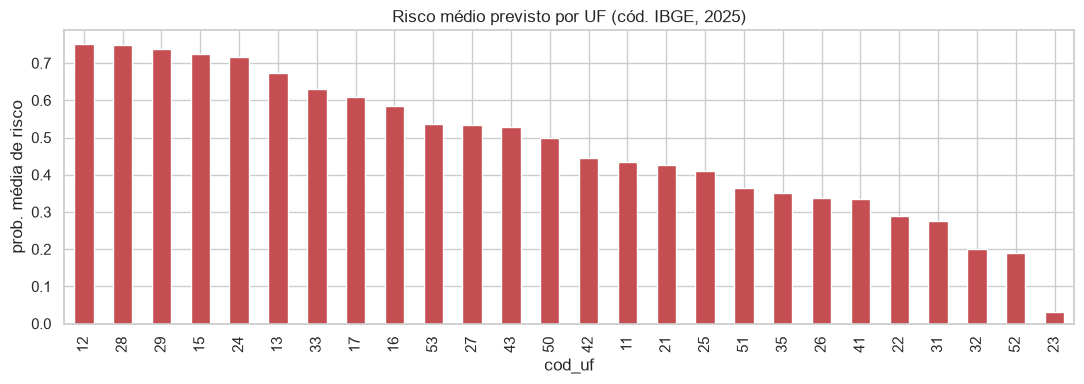

In [13]:
plots.risco_por_uf(pred, ano_base + 1); plt.show()


## 8. Conclusões e limitações

**Modelo:** Regressão Logística sobre 3 features do ano anterior. Holdout de
municípios: ROC-AUC ≈ 0,82, recall da classe de risco ≈ 0,76, ~12 p.p. de
acurácia acima do baseline. `GroupKFold` por UF confirma (ROC-AUC ≈ 0,84).

**Serve para:** priorizar municípios para acompanhamento — o ranking de
`prob_risco` é acionável (`reports/previsao_risco_2025.csv`).

**Não serve para:** cravar atingimento de meta anual (seção 6); previsão
multi-ano; identificar causas acionáveis (só há desempenho passado nas features).

**Limitações de dados:** só 2023 e 2024 (uma transição, sem holdout de ano
futuro); taxa municipal ruidosa (σ do Δ ≈ 16 p.p.), sobretudo em municípios
pequenos; sem variáveis socioeconômicas.

Detalhe completo em `reports/relatorio_tecnico.md`.
